CSV_PATH: /kaggle/input/datasets/googleai/musiccaps/musiccaps-public.csv
Using device: cuda
          ytid                                            caption  \
0  -0Gj8-vB1q4  The low quality recording features a ballad so...   
1  -0SdAVK79lg  This song features an electric guitar as the m...   
2  -0vPFx-wRRI  a male voice is singing a melody with changing...   
3  -0xzrMun0Rs  This song contains digital drums playing a sim...   
4  -1LrH01Ei1w  This song features a rubber instrument being p...   

                                      aspects_parsed  
0  [low quality, sustained strings melody, soft f...  
1  [guitar song, piano backing, simple percussion...  
2  [amateur recording, finger snipping, male mid ...  
3  [backing track, jazzy, digital drums, piano, e...  
4  [rubab instrument, repetitive melody on differ...  
Total captions: 5521
Total proxy tags (top 50 real aspects): 50
['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'a

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/15 | Loss: 0.2496 | Val Macro-F1: 0.0788 | Val Micro-F1: 0.2468
Epoch 2/15 | Loss: 0.1615 | Val Macro-F1: 0.2483 | Val Micro-F1: 0.4311
Epoch 3/15 | Loss: 0.1363 | Val Macro-F1: 0.2943 | Val Micro-F1: 0.4802
Epoch 4/15 | Loss: 0.1212 | Val Macro-F1: 0.3747 | Val Micro-F1: 0.5428
Epoch 5/15 | Loss: 0.1091 | Val Macro-F1: 0.4241 | Val Micro-F1: 0.5854
Epoch 6/15 | Loss: 0.0988 | Val Macro-F1: 0.4660 | Val Micro-F1: 0.5990
Epoch 7/15 | Loss: 0.0896 | Val Macro-F1: 0.5283 | Val Micro-F1: 0.6443
Epoch 8/15 | Loss: 0.0810 | Val Macro-F1: 0.5499 | Val Micro-F1: 0.6576
Epoch 9/15 | Loss: 0.0736 | Val Macro-F1: 0.5630 | Val Micro-F1: 0.6549
Epoch 10/15 | Loss: 0.0663 | Val Macro-F1: 0.5732 | Val Micro-F1: 0.6617
Epoch 11/15 | Loss: 0.0598 | Val Macro-F1: 0.5923 | Val Micro-F1: 0.6659
Epoch 12/15 | Loss: 0.0540 | Val Macro-F1: 0.6226 | Val Micro-F1: 0.6809
Epoch 13/15 | Loss: 0.0486 | Val Macro-F1: 0.6323 | Val Micro-F1: 0.6827
Epoch 14/15 | Loss: 0.0434 | Val Macro-F1: 0.6206 | Val Micr

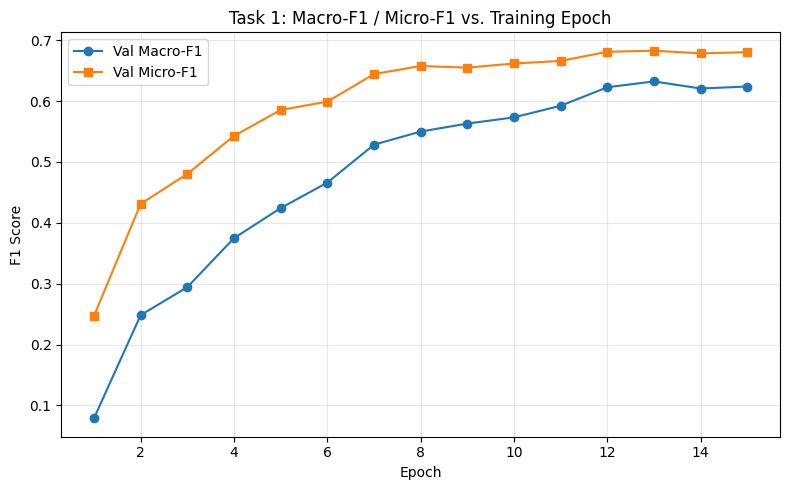

F1 curve plot saved to task1_f1_curves.png

Final Test Macro-F1: 0.6274
Final Test Micro-F1: 0.6956

Per-tag report:
                    precision    recall  f1-score   support

       low quality       0.97      0.99      0.98       117
      instrumental       0.86      0.74      0.79        96
         emotional       0.76      0.65      0.70        63
             noisy       0.94      0.81      0.87        62
        passionate       0.73      0.69      0.71        59
      medium tempo       0.67      0.65      0.66        48
         energetic       0.68      0.58      0.62        59
 amateur recording       0.82      0.47      0.59        58
  live performance       1.00      0.67      0.80        45
        slow tempo       0.69      0.43      0.53        51
    acoustic drums       0.92      0.69      0.79        32
        fast tempo       0.81      0.64      0.71        47
              mono       1.00      0.97      0.98        32
            groovy       0.53      0.36   

In [1]:
"""
TASK 1: BERT Baseline for Music Tag Understanding — FINAL COMPLETE VERSION
==============================================================================
Run this in a Kaggle Notebook.

BEFORE RUNNING:
1. Add Input: "MusicCaps" (googleai/musiccaps) via the "+" button
2. Settings -> Accelerator -> GPU T4 x2

Dataset: official MusicCaps (musiccaps-public.csv), using the real
"aspect_list" column (musician-written ground-truth tags). Top-50 most
frequent aspects are used as the tag vocabulary.

Guideline compliance included in this version:
- Label leakage prevention: matched aspect phrases are masked out of
  the caption ([MASK]) before being given to BERT as input.
- Macro-F1 / Micro-F1 CURVES vs. training epoch (actual plot, not just
  printed numbers) — required deliverable.
- 5 example predictions — required deliverable.
- B1 majority-class baseline comparison — required minimum baseline.

Copy-paste each "# %% CELL" block into a separate Kaggle notebook cell.
"""

# %% CELL 1 — Install dependencies
!pip install transformers scikit-learn matplotlib -q

# %% CELL 2 — Auto-detect the MusicCaps CSV path
import os

INPUT_ROOT = "/kaggle/input"

def find_path(base_dir, target_name, is_file=False):
    for root, dirs, files_in_dir in os.walk(base_dir):
        if is_file and target_name in files_in_dir:
            return os.path.join(root, target_name)
        if not is_file and target_name in dirs:
            return os.path.join(root, target_name)
    return None

CSV_PATH = find_path(INPUT_ROOT, "musiccaps-public.csv", is_file=True)
print(f"CSV_PATH: {CSV_PATH}")
assert CSV_PATH is not None, "musiccaps-public.csv not found — did you add the MusicCaps dataset via the '+' button?"

WORKING_DIR = "/kaggle/working"

# %% CELL 3 — Imports & Config
import re
import ast
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from collections import Counter

CHECKPOINT_PATH = os.path.join(WORKING_DIR, "task1_checkpoint.pt")
MAX_LEN = 128
BATCH_SIZE = 16
NUM_EPOCHS = 15
LR = 2e-5
TOP_N_TAGS = 50   # how many most-frequent aspects to use as the tag vocabulary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# %% CELL 4 — Load captions and parse aspect_list
df = pd.read_csv(CSV_PATH)
df['aspects_parsed'] = df['aspect_list'].apply(ast.literal_eval)
df['aspects_parsed'] = df['aspects_parsed'].apply(lambda lst: [a.strip().lower() for a in lst])

print(df[['ytid', 'caption', 'aspects_parsed']].head())
print(f"Total captions: {len(df)}")

# %% CELL 5 — Build tag vocabulary from top-N most frequent real aspects
all_aspects = []
for lst in df['aspects_parsed']:
    all_aspects.extend(lst)

counter = Counter(all_aspects)
TAG_NAMES = [tag for tag, _ in counter.most_common(TOP_N_TAGS)]
NUM_TAGS = len(TAG_NAMES)
print(f"Total proxy tags (top {TOP_N_TAGS} real aspects): {NUM_TAGS}")
print(TAG_NAMES)

def build_labels_and_masked_caption(row):
    """
    Build a multi-hot label vector from real aspect_list tags (only the
    ones in our top-N vocabulary), and mask those matched phrases out
    of the caption text to prevent label leakage — without this, BERT
    could just detect the literal keyword instead of learning genuine
    context, inflating F1 to near-100% with no real learning.
    """
    aspects_present = set(row['aspects_parsed'])
    labels = np.zeros(NUM_TAGS, dtype=np.float32)
    masked = row['caption']

    for i, tag in enumerate(TAG_NAMES):
        if tag in aspects_present:
            labels[i] = 1.0
            masked = re.sub(re.escape(tag), "[MASK]", masked, flags=re.IGNORECASE)

    return labels, masked

results = df.apply(build_labels_and_masked_caption, axis=1)
df['labels'] = results.apply(lambda r: r[0])
df['masked_caption'] = results.apply(lambda r: r[1])

no_tag_count = sum(1 for l in df['labels'] if l.sum() == 0)
print(f"\nNo-tag captions (none of the top-{TOP_N_TAGS} aspects matched): {no_tag_count} / {len(df)}")
print("\nExample of masking:")
print(f"Original: {df['caption'].iloc[0]}")
print(f"Masked:   {df['masked_caption'].iloc[0]}")

# %% CELL 6 — Train/Val/Test split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# %% CELL 7 — Dataset class
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class CaptionTagDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=MAX_LEN):
        self.captions = dataframe['masked_caption'].tolist()   # masked, not raw caption
        self.labels = np.stack(dataframe['labels'].tolist())
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.captions[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

train_dataset = CaptionTagDataset(train_df, tokenizer)
val_dataset = CaptionTagDataset(val_df, tokenizer)
test_dataset = CaptionTagDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# %% CELL 8 — BERT Multi-label Classifier Model
class BERTTagClassifier(nn.Module):
    def __init__(self, num_tags=NUM_TAGS):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_tags)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]   # CLS token
        cls_output = self.dropout(cls_output)
        return self.classifier(cls_output)   # sigmoid is applied inside BCEWithLogitsLoss

# %% CELL 9 — Training setup
model = BERTTagClassifier().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

def train_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(loader, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        preds = (torch.sigmoid(outputs) > threshold).float()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    return macro_f1, micro_f1, all_preds, all_labels

# %% CELL 10 — Resume from checkpoint (if it exists) + Training loop
# Track Macro-F1 / Micro-F1 per epoch for the required curve plot (CELL 11)
history = {"epoch": [], "train_loss": [], "val_macro_f1": [], "val_micro_f1": []}

start_epoch = 0
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch'] + 1
    history = ckpt.get('history', history)
    print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss = train_epoch()
    val_macro_f1, val_micro_f1, _, _ = evaluate(val_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | Val Macro-F1: {val_macro_f1:.4f} | Val Micro-F1: {val_micro_f1:.4f}")

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_micro_f1"].append(val_micro_f1)

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'history': history,
    }, CHECKPOINT_PATH)

# %% CELL 11 — REQUIRED DELIVERABLE: Macro-F1 / Micro-F1 curves vs. training epoch
plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["val_macro_f1"], marker='o', label="Val Macro-F1")
plt.plot(history["epoch"], history["val_micro_f1"], marker='s', label="Val Micro-F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Task 1: Macro-F1 / Micro-F1 vs. Training Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, "task1_f1_curves.png"), dpi=150)
plt.show()
print("F1 curve plot saved to task1_f1_curves.png")

# %% CELL 12 — Final Test Evaluation
test_macro_f1, test_micro_f1, test_preds, test_labels = evaluate(test_loader)
print(f"\nFinal Test Macro-F1: {test_macro_f1:.4f}")
print(f"Final Test Micro-F1: {test_micro_f1:.4f}")
print("\nPer-tag report:")
print(classification_report(test_labels, test_preds, target_names=TAG_NAMES, zero_division=0))

# %% CELL 13 — REQUIRED DELIVERABLE: 5 example predictions
model.eval()
sample_df = test_df.sample(5, random_state=1)
example_predictions = []
for _, row in sample_df.iterrows():
    encoding = tokenizer(row['masked_caption'], truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt').to(device)
    with torch.no_grad():
        output = model(encoding['input_ids'], encoding['attention_mask'])
        probs = torch.sigmoid(output).cpu().numpy()[0]
    predicted_tags = [TAG_NAMES[i] for i, p in enumerate(probs) if p > 0.5]
    actual_tags = [TAG_NAMES[i] for i, v in enumerate(row['labels']) if v == 1.0]
    print(f"\nOriginal caption: {row['caption'][:100]}...")
    print(f"Model saw (masked): {row['masked_caption'][:100]}...")
    print(f"Actual tags: {actual_tags}")
    print(f"Predicted tags: {predicted_tags}")
    example_predictions.append({
        "caption": row['caption'], "actual_tags": actual_tags, "predicted_tags": predicted_tags
    })

# %% CELL 14 — REQUIRED BASELINE: B1 Majority-Class comparison
# Predicts each tag independently at its overall training-set frequency
# (base rate), thresholded at 0.5 — the simplest required baseline (B1).
train_labels_arr = np.stack(train_df['labels'].tolist())
tag_base_rates = train_labels_arr.mean(axis=0)
b1_pred_vector = (tag_base_rates > 0.5).astype(np.float32)   # same prediction for every sample
b1_preds_repeated = np.tile(b1_pred_vector, (len(test_labels), 1))

b1_macro_f1 = f1_score(test_labels, b1_preds_repeated, average='macro', zero_division=0)
b1_micro_f1 = f1_score(test_labels, b1_preds_repeated, average='micro', zero_division=0)

print(f"\n--- B1 Majority-Class Baseline vs. BERT ---")
print(f"B1 Baseline: Macro-F1 {b1_macro_f1:.4f}, Micro-F1 {b1_micro_f1:.4f}")
print(f"BERT (this model): Macro-F1 {test_macro_f1:.4f}, Micro-F1 {test_micro_f1:.4f}")

# %% CELL 15 — Save all results
results = {
    "test_macro_f1": float(test_macro_f1),
    "test_micro_f1": float(test_micro_f1),
    "b1_baseline_macro_f1": float(b1_macro_f1),
    "b1_baseline_micro_f1": float(b1_micro_f1),
    "tag_names": TAG_NAMES,
    "history": history,
    "example_predictions": example_predictions,
}
RESULTS_PATH = os.path.join(WORKING_DIR, "task1_results.json")
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nCheckpoint saved at: {CHECKPOINT_PATH}")
print(f"Results saved at: {RESULTS_PATH}")
print(f"F1 curve plot saved at: {os.path.join(WORKING_DIR, 'task1_f1_curves.png')}")
print("\nIMPORTANT: click 'Save Version' (top right) now, or these files")
print("will be lost when this session ends.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00
FMA_AUDIO_DIR: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_small/fma_small
TRACKS_CSV: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
Using device: cuda
Total genres: 8
['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']

Official split distribution:
(set, split)
training      6400
validation     800
test           800
Name: count, dtype: int64
Processed: 200, Skipped: 0
Processed: 400, Skipped: 0


[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!


Processed: 600, Skipped: 0
Processed: 800, Skipped: 0


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Processed: 1000, Skipped: 0


...

Processed: 5000, Skipped: 5
Processed: 5200, Skipped: 5
Processed: 5400, Skipped: 5
Processed: 5600, Skipped: 5
Processed: 5800, Skipped: 5
Processed: 6000, Skipped: 5


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processed: 6200, Skipped: 5
Processed: 6400, Skipped: 5
Processed: 6600, Skipped: 5
Processed: 6800, Skipped: 5


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/tmp/ipykernel_23/598857265.py:116: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(audio_path, sr=sr, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processed: 7000, Skipped: 6
Processed: 7200, Skipped: 6
Processed: 7400, Skipped: 6
Processed: 7600, Skipped: 6
Processed: 7800, Skipped: 6
DONE. Processed: 7994, Skipped: 6
GNN — Train: 6394, Val: 800, Test: 800 (official FMA split)

B1 Majority-Class Baseline — Test Accuracy: 0.1250, Macro-F1: 0.0278
(Majority genre: Folk)
[GNN] Epoch 1/50 | Loss: 1.9988 | Val Acc: 0.2062
[GNN] Epoch 2/50 | Loss: 1.9280 | Val Acc: 0.2213
[GNN] Epoch 3/50 | Loss: 1.9130 | Val Acc: 0.2137
[GNN] Epoch 4/50 | Loss: 1.8997 | Val Acc: 0.2525
[GNN] Epoch 5/50 | Loss: 1.8928 | Val Acc: 0.2288
[GNN] Epoch 6/50 | Loss: 1.8809 | Val Acc: 0.2500
[GNN] Epoch 7/50 | Loss: 1.8667 | Val Acc: 0.2650
[GNN] Epoch 8/50 | Loss: 1.8603 | Val Acc: 0.2512
[GNN] Epoch 9/50 | Loss: 1.8492 | Val Acc: 0.2938
[GNN] Epoch 10/50 | Loss: 1.8462 | Val Acc: 0.2625
[GNN] Epoch 11/50 | Loss: 1.8400 | Val Acc: 0.2838
[GNN] Epoch 12/50 | Loss: 1.8377 | Val Acc: 0.2637
[GNN] Epoch 13/50 | Loss: 1.8296 | Val Acc: 0.2500
[GNN] Epoch 14/50 |

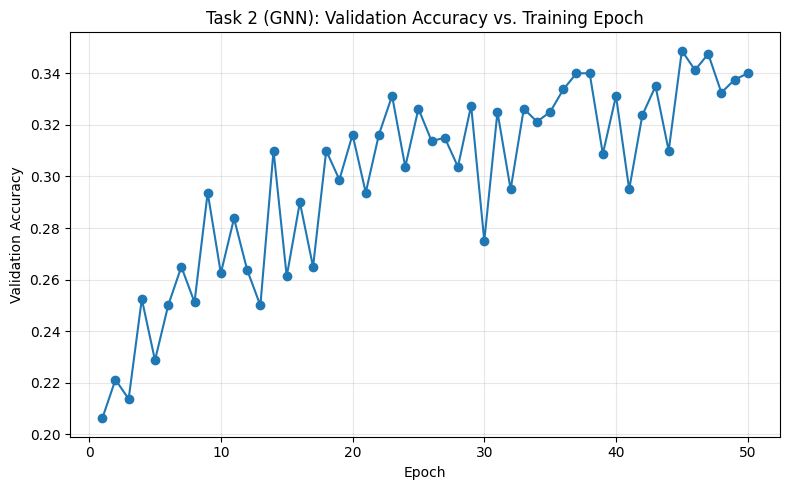


GNN Final Test Accuracy: 0.3312
GNN Macro-F1: 0.3047
GNN Micro-F1: 0.3312
               precision    recall  f1-score   support

   Electronic       0.33      0.30      0.31       100
 Experimental       0.20      0.05      0.08       100
         Folk       0.31      0.39      0.34       100
      Hip-Hop       0.46      0.59      0.52       100
 Instrumental       0.32      0.59      0.42       100
International       0.35      0.14      0.20       100
          Pop       0.35      0.19      0.25       100
         Rock       0.26      0.40      0.32       100

     accuracy                           0.33       800
    macro avg       0.32      0.33      0.30       800
 weighted avg       0.32      0.33      0.30       800



[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!


Processed: 500, Skipped: 0


[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


Processed: 1000, Skipped: 0


...

Processed: 4500, Skipped: 2


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/tmp/ipykernel_23/598857265.py:351: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=15)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processed: 5000, Skipped: 3
Processed: 5500, Skipped: 3
Processed: 6000, Skipped: 3
Processed: 6500, Skipped: 3


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/tmp/ipykernel_23/598857265.py:351: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=15)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processed: 7000, Skipped: 4
Processed: 7500, Skipped: 4
DONE. Processed: 7996, Skipped: 4
Usable tracks for CNN: 7996
CNN — Train: 6396, Val: 800, Test: 800 (official FMA split)
[CNN] Epoch 1/30 | Loss: 1.9436 | Val Acc: 0.3713
[CNN] Epoch 2/30 | Loss: 1.6815 | Val Acc: 0.4387
[CNN] Epoch 3/30 | Loss: 1.5518 | Val Acc: 0.4462
[CNN] Epoch 4/30 | Loss: 1.4905 | Val Acc: 0.4863
[CNN] Epoch 5/30 | Loss: 1.4392 | Val Acc: 0.4888
[CNN] Epoch 6/30 | Loss: 1.4117 | Val Acc: 0.4713
[CNN] Epoch 7/30 | Loss: 1.3793 | Val Acc: 0.5387
[CNN] Epoch 8/30 | Loss: 1.3364 | Val Acc: 0.5138
[CNN] Epoch 9/30 | Loss: 1.3126 | Val Acc: 0.5262
[CNN] Epoch 10/30 | Loss: 1.2795 | Val Acc: 0.5075
[CNN] Epoch 11/30 | Loss: 1.2726 | Val Acc: 0.5513
[CNN] Epoch 12/30 | Loss: 1.2523 | Val Acc: 0.5188
[CNN] Epoch 13/30 | Loss: 1.2240 | Val Acc: 0.5450
[CNN] Epoch 14/30 | Loss: 1.2091 | Val Acc: 0.5300
[CNN] Epoch 15/30 | Loss: 1.1845 | Val Acc: 0.5125
[CNN] Epoch 16/30 | Loss: 1.1698 | Val Acc: 0.5275
[CNN] Epoch 17/

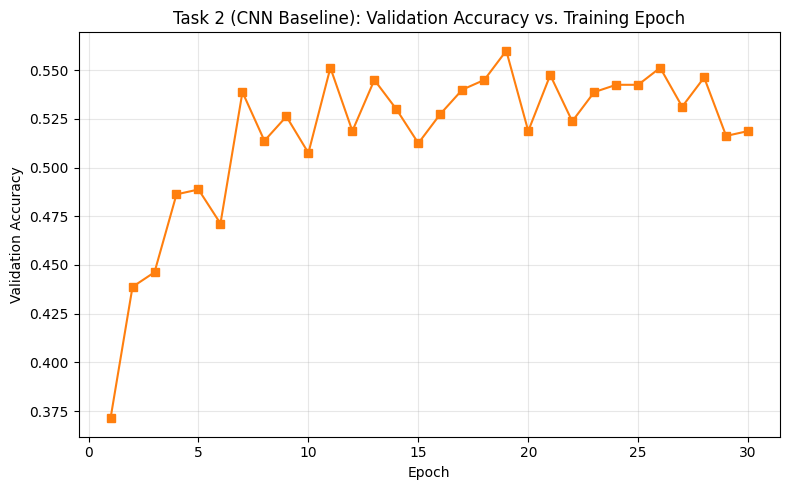


CNN Baseline Final Test Accuracy: 0.4450
CNN Baseline Macro-F1: 0.4414
CNN Baseline Micro-F1: 0.4450
               precision    recall  f1-score   support

   Electronic       0.55      0.48      0.51       100
 Experimental       0.36      0.30      0.33       100
         Folk       0.24      0.26      0.25       100
      Hip-Hop       0.58      0.86      0.69       100
 Instrumental       0.33      0.31      0.32       100
International       0.56      0.46      0.51       100
          Pop       0.26      0.30      0.28       100
         Rock       0.71      0.59      0.64       100

     accuracy                           0.45       800
    macro avg       0.45      0.45      0.44       800
 weighted avg       0.45      0.45      0.44       800


TASK 2 — FINAL BASELINE COMPARISON (official FMA split)
Model                    Accuracy    Macro-F1    
B1 (Majority-class)      0.1250      0.0278      
B2 (CNN mel-spectrogram) 0.4450      0.4414      
GNN (GraphSAGE, ours)    0.3

In [2]:
"""
TASK 2: GNN on Music Structure Graphs (FMA-small) — FINAL COMPLETE VERSION
==============================================================================
Run this in a Kaggle Notebook.

BEFORE RUNNING:
1. Add Input: "FMA - Free Music Archive - Small & Medium" (imsparsh/...)
2. Settings -> Accelerator -> GPU T4 x2

Dataset: FMA-small (same as before) — 8,000 tracks, 8 genres.

Guideline compliance included in this version:
- OFFICIAL FMA split (not random) — the assignment requires "Use
  official FMA / MagnaTagATune splits" and "no artist leakage across
  train/test"; FMA's own ('set','split') column satisfies both.
- B1 baseline: majority-class predictor (required minimum baseline).
- B2 baseline: CNN on mel-spectrogram (required deliverable: "Comparison
  vs. CNN baseline on mel-spectrogram").
- GNN (GraphSAGE) on chroma segment-graphs — the main model.
- Accuracy/F1 curve plot vs. training epoch for both GNN and CNN.
- Final 3-way comparison table (B1 vs CNN vs GNN).

Copy-paste each "# %% CELL" block into a separate Kaggle notebook cell.
This is long — expect the full run (preprocessing + GNN + CNN training)
to take a while; preprocessing is CPU-only, so if you want to save GPU
quota, you can run CELL 1-8 (graph preprocessing) with the accelerator
set to None, then switch to GPU before CELL 9 onward.
"""

# %% CELL 1 — Install dependencies
!pip install torch-geometric -q

# %% CELL 2 — Imports & Auto-detect dataset paths
import os
import json
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset as TorchDataset, DataLoader as TorchDataLoader
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import classification_report, f1_score, accuracy_score

INPUT_ROOT = "/kaggle/input"

def find_path(base_dir, target_name, is_file=False):
    for root, dirs, files_in_dir in os.walk(base_dir):
        if is_file and target_name in files_in_dir:
            return os.path.join(root, target_name)
        if not is_file and target_name in dirs:
            return os.path.join(root, target_name)
    return None

def find_audio_root(base_dir):
    """Finds the folder directly containing genre subfolders (000, 001, ...)
    with .mp3 files, handling any nested 'fma_small/fma_small/...' structure."""
    for root, dirs, files_in_dir in os.walk(base_dir):
        if any(f.endswith('.mp3') for f in files_in_dir):
            return os.path.dirname(root)
    return None

FMA_SMALL_CANDIDATE = find_path(INPUT_ROOT, "fma_small")
FMA_AUDIO_DIR = find_audio_root(FMA_SMALL_CANDIDATE) if FMA_SMALL_CANDIDATE else find_audio_root(INPUT_ROOT)
TRACKS_CSV = find_path(INPUT_ROOT, "tracks.csv", is_file=True)

print(f"FMA_AUDIO_DIR: {FMA_AUDIO_DIR}")
print(f"TRACKS_CSV: {TRACKS_CSV}")
assert FMA_AUDIO_DIR is not None, "fma_small mp3 files not found — did you add the dataset via 'Add Input'?"
assert TRACKS_CSV is not None, "tracks.csv not found — did you add the dataset via 'Add Input'?"

WORKING_DIR = "/kaggle/working"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

SEGMENT_DURATION = 5.0
SAMPLE_RATE = 22050
N_CHROMA = 12
SIMILARITY_THRESHOLD = 0.85
N_MELS = 128
FIXED_FRAMES = 640   # ~15s worth of frames at hop_length=512, fixed size for CNN input

# %% CELL 3 — Load metadata (genre labels + OFFICIAL FMA split)
tracks = pd.read_csv(TRACKS_CSV, index_col=0, header=[0, 1])
small_subset = tracks[tracks[('set', 'subset')] == 'small']
genre_labels = small_subset[('track', 'genre_top')].dropna()
official_split = small_subset[('set', 'split')]   # 'training' / 'validation' / 'test'

unique_genres = sorted(genre_labels.unique())
genre_to_idx = {g: i for i, g in enumerate(unique_genres)}
NUM_CLASSES = len(unique_genres)
print(f"Total genres: {NUM_CLASSES}")
print(unique_genres)
print(f"\nOfficial split distribution:\n{official_split.loc[genre_labels.index].value_counts()}")

def track_id_to_path(track_id):
    tid_str = f"{track_id:06d}"
    return os.path.join(FMA_AUDIO_DIR, tid_str[:3], f"{tid_str}.mp3")

# ============================================================
# PART A: GNN on Chroma Segment-Graphs (main model)
# ============================================================

# %% CELL 4 — Audio to Segment Graph builder
def build_segment_graph(audio_path, segment_duration=SEGMENT_DURATION, sr=SAMPLE_RATE):
    """
    Builds a segment-graph from one audio file:
    - Node = chroma feature (mean-pooled, 12-dim) for each 5-second window
    - Edge = temporal adjacency + cosine similarity above threshold
    """
    try:
        y, _ = librosa.load(audio_path, sr=sr, duration=30)
    except Exception:
        return None
    if len(y) < sr:
        return None

    hop_length = 512
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=hop_length)
    frames_per_segment = int(segment_duration * sr / hop_length)
    n_segments = max(1, chroma.shape[1] // frames_per_segment)

    node_features = []
    for i in range(n_segments):
        start = i * frames_per_segment
        end = min(start + frames_per_segment, chroma.shape[1])
        node_features.append(chroma[:, start:end].mean(axis=1))
    if len(node_features) < 2:
        return None
    node_features = np.stack(node_features)

    edges = []
    for i in range(len(node_features)):
        if i + 1 < len(node_features):
            edges.append([i, i + 1]); edges.append([i + 1, i])
        for j in range(i + 1, len(node_features)):
            sim = np.dot(node_features[i], node_features[j]) / (
                np.linalg.norm(node_features[i]) * np.linalg.norm(node_features[j]) + 1e-8)
            if sim > SIMILARITY_THRESHOLD:
                edges.append([i, j]); edges.append([j, i])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    x = torch.tensor(node_features, dtype=torch.float)
    return x, edge_index

# %% CELL 5 — Preprocess all tracks into cached graph files (reuse if available)
GRAPH_CACHE_DIR = os.path.join(WORKING_DIR, "fma_graphs_cache")
EXISTING_GRAPH_CACHE = find_path(INPUT_ROOT, "fma_graphs_cache")
if EXISTING_GRAPH_CACHE is not None and len(os.listdir(EXISTING_GRAPH_CACHE)) > 0:
    GRAPH_CACHE_DIR = EXISTING_GRAPH_CACHE
    print(f"Reusing existing graph cache: {GRAPH_CACHE_DIR} ({len(os.listdir(GRAPH_CACHE_DIR))} files)")
else:
    os.makedirs(GRAPH_CACHE_DIR, exist_ok=True)

def preprocess_all_tracks():
    processed, skipped = 0, 0
    for track_id, genre in genre_labels.items():
        cache_path = os.path.join(GRAPH_CACHE_DIR, f"{track_id}.pt")
        if os.path.exists(cache_path):
            continue
        audio_path = track_id_to_path(track_id)
        if not os.path.exists(audio_path):
            skipped += 1
            continue
        result = build_segment_graph(audio_path)
        if result is None:
            skipped += 1
            continue
        x, edge_index = result
        y = torch.tensor([genre_to_idx[genre]], dtype=torch.long)
        data = Data(x=x, edge_index=edge_index, y=y)
        torch.save(data, cache_path)
        processed += 1
        if processed % 200 == 0:
            print(f"Processed: {processed}, Skipped: {skipped}")
    print(f"DONE. Processed: {processed}, Skipped: {skipped}")

if EXISTING_GRAPH_CACHE is None:
    preprocess_all_tracks()

# %% CELL 6 — Dataset class + OFFICIAL split (not random)
class FMAGraphDataset(PyGDataset):
    def __init__(self, cache_dir):
        super().__init__()
        self.files = [os.path.join(cache_dir, f) for f in os.listdir(cache_dir) if f.endswith('.pt')]
        self.track_ids = [int(os.path.basename(f).replace('.pt', '')) for f in self.files]

    def len(self):
        return len(self.files)

    def get(self, idx):
        return torch.load(self.files[idx], weights_only=False)

full_dataset = FMAGraphDataset(GRAPH_CACHE_DIR)

train_indices, val_indices, test_indices = [], [], []
for i, tid in enumerate(full_dataset.track_ids):
    split_label = official_split.get(tid, "training")
    if split_label == "training":
        train_indices.append(i)
    elif split_label == "validation":
        val_indices.append(i)
    else:
        test_indices.append(i)

train_set = torch.utils.data.Subset(full_dataset, train_indices)
val_set = torch.utils.data.Subset(full_dataset, val_indices)
test_set = torch.utils.data.Subset(full_dataset, test_indices)

train_loader = PyGDataLoader(train_set, batch_size=32, shuffle=True)
val_loader = PyGDataLoader(val_set, batch_size=32)
test_loader = PyGDataLoader(test_set, batch_size=32)
print(f"GNN — Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)} (official FMA split)")

# %% CELL 7 — B1 BASELINE: Majority-class predictor
majority_genre = genre_labels.loc[[full_dataset.track_ids[i] for i in train_indices]].value_counts().idxmax()
test_true_genres = [genre_labels[full_dataset.track_ids[i]] for i in test_indices]
b1_preds = [majority_genre] * len(test_true_genres)

b1_acc = accuracy_score(test_true_genres, b1_preds)
b1_macro_f1 = f1_score(test_true_genres, b1_preds, average='macro', zero_division=0)
print(f"\nB1 Majority-Class Baseline — Test Accuracy: {b1_acc:.4f}, Macro-F1: {b1_macro_f1:.4f}")
print(f"(Majority genre: {majority_genre})")

# %% CELL 8 — GraphSAGE Model
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels=N_CHROMA, hidden_channels=64, num_classes=NUM_CLASSES, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList([SAGEConv(in_channels, hidden_channels)])
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.classifier = nn.Linear(hidden_channels, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = self.dropout(x)
        g = global_mean_pool(x, batch)
        return self.classifier(g)

gnn_model = GraphSAGEClassifier().to(device)
gnn_optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=5e-4)
gnn_criterion = nn.CrossEntropyLoss()
GNN_CHECKPOINT_PATH = os.path.join(WORKING_DIR, "task2_gnn_checkpoint.pt")

def gnn_train_epoch():
    gnn_model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        gnn_optimizer.zero_grad()
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        loss = gnn_criterion(out, batch.y)
        loss.backward()
        gnn_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def gnn_evaluate(loader):
    gnn_model.eval()
    correct, total = 0, 0
    for batch in loader:
        batch = batch.to(device)
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.num_graphs
    return correct / total

# %% CELL 9 — GNN Training loop (with history for the required curve plot)
gnn_history = {"epoch": [], "train_loss": [], "val_acc": []}
start_epoch = 0
if os.path.exists(GNN_CHECKPOINT_PATH):
    ckpt = torch.load(GNN_CHECKPOINT_PATH, weights_only=False, map_location=device)
    gnn_model.load_state_dict(ckpt['model_state'])
    gnn_optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch'] + 1
    gnn_history = ckpt.get('history', gnn_history)
    print(f"Resumed from epoch {start_epoch}")

NUM_EPOCHS_GNN = 50
for epoch in range(start_epoch, NUM_EPOCHS_GNN):
    train_loss = gnn_train_epoch()
    val_acc = gnn_evaluate(val_loader)
    print(f"[GNN] Epoch {epoch+1}/{NUM_EPOCHS_GNN} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    gnn_history["epoch"].append(epoch + 1)
    gnn_history["train_loss"].append(train_loss)
    gnn_history["val_acc"].append(val_acc)

    torch.save({
        'epoch': epoch, 'model_state': gnn_model.state_dict(),
        'optimizer_state': gnn_optimizer.state_dict(), 'history': gnn_history,
    }, GNN_CHECKPOINT_PATH)

# %% CELL 10 — GNN Accuracy curve plot (required visualization)
plt.figure(figsize=(8, 5))
plt.plot(gnn_history["epoch"], gnn_history["val_acc"], marker='o', color='tab:blue')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Task 2 (GNN): Validation Accuracy vs. Training Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, "task2_gnn_accuracy_curve.png"), dpi=150)
plt.show()

# %% CELL 11 — GNN Final Test Evaluation
@torch.no_grad()
def gnn_get_predictions(loader):
    gnn_model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    return all_preds, all_labels

gnn_test_acc = gnn_evaluate(test_loader)
gnn_preds, gnn_labels = gnn_get_predictions(test_loader)
gnn_macro_f1 = f1_score(gnn_labels, gnn_preds, average='macro')
gnn_micro_f1 = f1_score(gnn_labels, gnn_preds, average='micro')

print(f"\nGNN Final Test Accuracy: {gnn_test_acc:.4f}")
print(f"GNN Macro-F1: {gnn_macro_f1:.4f}")
print(f"GNN Micro-F1: {gnn_micro_f1:.4f}")
print(classification_report(gnn_labels, gnn_preds, target_names=unique_genres))

# ============================================================
# PART B: CNN Baseline (B2) on Mel-Spectrogram
# ============================================================

# %% CELL 12 — Mel-spectrogram extraction (reuse if cached)
MEL_CACHE_DIR = os.path.join(WORKING_DIR, "mel_cache")
EXISTING_MEL_CACHE = find_path(INPUT_ROOT, "mel_cache")
if EXISTING_MEL_CACHE is not None and len(os.listdir(EXISTING_MEL_CACHE)) > 0:
    MEL_CACHE_DIR = EXISTING_MEL_CACHE
    print(f"Reusing existing mel cache: {MEL_CACHE_DIR} ({len(os.listdir(MEL_CACHE_DIR))} files)")
else:
    os.makedirs(MEL_CACHE_DIR, exist_ok=True)

def extract_mel(audio_path):
    try:
        y, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=15)
    except Exception:
        return None
    if len(y) < SAMPLE_RATE:
        return None
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < FIXED_FRAMES:
        mel_db = np.pad(mel_db, ((0, 0), (0, FIXED_FRAMES - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :FIXED_FRAMES]
    return mel_db.astype(np.float32)

def preprocess_mel_all():
    processed, skipped = 0, 0
    for track_id, genre in genre_labels.items():
        cache_path = os.path.join(MEL_CACHE_DIR, f"{track_id}.npy")
        if os.path.exists(cache_path):
            continue
        audio_path = track_id_to_path(track_id)
        if not os.path.exists(audio_path):
            skipped += 1
            continue
        mel = extract_mel(audio_path)
        if mel is None:
            skipped += 1
            continue
        np.save(cache_path, mel)
        processed += 1
        if processed % 500 == 0:
            print(f"Processed: {processed}, Skipped: {skipped}")
    print(f"DONE. Processed: {processed}, Skipped: {skipped}")

if EXISTING_MEL_CACHE is None:
    preprocess_mel_all()

# %% CELL 13 — CNN Dataset class using the SAME official split
valid_mel_ids = [tid for tid in genre_labels.index if os.path.exists(os.path.join(MEL_CACHE_DIR, f"{tid}.npy"))]
print(f"Usable tracks for CNN: {len(valid_mel_ids)}")

mel_train_ids = [tid for tid in valid_mel_ids if official_split.get(tid) == "training"]
mel_val_ids = [tid for tid in valid_mel_ids if official_split.get(tid) == "validation"]
mel_test_ids = [tid for tid in valid_mel_ids if official_split.get(tid) == "test"]
print(f"CNN — Train: {len(mel_train_ids)}, Val: {len(mel_val_ids)}, Test: {len(mel_test_ids)} (official FMA split)")

class MelDataset(TorchDataset):
    def __init__(self, track_ids):
        self.track_ids = track_ids

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, i):
        tid = self.track_ids[i]
        mel = np.load(os.path.join(MEL_CACHE_DIR, f"{tid}.npy"))
        mel = (mel - mel.mean()) / (mel.std() + 1e-8)
        x = torch.tensor(mel, dtype=torch.float).unsqueeze(0)
        y = torch.tensor(genre_to_idx[genre_labels[tid]], dtype=torch.long)
        return x, y

cnn_train_loader = TorchDataLoader(MelDataset(mel_train_ids), batch_size=32, shuffle=True)
cnn_val_loader = TorchDataLoader(MelDataset(mel_val_ids), batch_size=32)
cnn_test_loader = TorchDataLoader(MelDataset(mel_test_ids), batch_size=32)

# %% CELL 14 — CNN Model + Training
class MelCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 4 * 4, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.conv(x))

cnn_model = MelCNN().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_criterion = nn.CrossEntropyLoss()
CNN_CHECKPOINT_PATH = os.path.join(WORKING_DIR, "task2_cnn_checkpoint.pt")

def cnn_train_epoch():
    cnn_model.train()
    total_loss = 0
    for x, y in cnn_train_loader:
        x, y = x.to(device), y.to(device)
        cnn_optimizer.zero_grad()
        out = cnn_model(x)
        loss = cnn_criterion(out, y)
        loss.backward()
        cnn_optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(cnn_train_loader.dataset)

@torch.no_grad()
def cnn_evaluate(loader):
    cnn_model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = cnn_model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

cnn_history = {"epoch": [], "train_loss": [], "val_acc": []}
start_epoch_cnn = 0
if os.path.exists(CNN_CHECKPOINT_PATH):
    ckpt = torch.load(CNN_CHECKPOINT_PATH, weights_only=False, map_location=device)
    cnn_model.load_state_dict(ckpt['model_state'])
    cnn_optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch_cnn = ckpt['epoch'] + 1
    cnn_history = ckpt.get('history', cnn_history)
    print(f"Resumed CNN from epoch {start_epoch_cnn}")

NUM_EPOCHS_CNN = 30
for epoch in range(start_epoch_cnn, NUM_EPOCHS_CNN):
    train_loss = cnn_train_epoch()
    val_acc = cnn_evaluate(cnn_val_loader)
    print(f"[CNN] Epoch {epoch+1}/{NUM_EPOCHS_CNN} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    cnn_history["epoch"].append(epoch + 1)
    cnn_history["train_loss"].append(train_loss)
    cnn_history["val_acc"].append(val_acc)

    torch.save({
        'epoch': epoch, 'model_state': cnn_model.state_dict(),
        'optimizer_state': cnn_optimizer.state_dict(), 'history': cnn_history,
    }, CNN_CHECKPOINT_PATH)

# %% CELL 15 — CNN Accuracy curve + Final Evaluation
plt.figure(figsize=(8, 5))
plt.plot(cnn_history["epoch"], cnn_history["val_acc"], marker='s', color='tab:orange')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Task 2 (CNN Baseline): Validation Accuracy vs. Training Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, "task2_cnn_accuracy_curve.png"), dpi=150)
plt.show()

@torch.no_grad()
def cnn_get_predictions(loader):
    cnn_model.eval()
    all_preds, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        pred = cnn_model(x).argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.numpy())
    return all_preds, all_labels

cnn_test_acc = cnn_evaluate(cnn_test_loader)
cnn_preds, cnn_labels = cnn_get_predictions(cnn_test_loader)
cnn_macro_f1 = f1_score(cnn_labels, cnn_preds, average='macro')
cnn_micro_f1 = f1_score(cnn_labels, cnn_preds, average='micro')

print(f"\nCNN Baseline Final Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Baseline Macro-F1: {cnn_macro_f1:.4f}")
print(f"CNN Baseline Micro-F1: {cnn_micro_f1:.4f}")
print(classification_report(cnn_labels, cnn_preds, target_names=unique_genres))

# %% CELL 16 — FINAL 3-WAY COMPARISON TABLE + Save all results
print("\n" + "=" * 60)
print("TASK 2 — FINAL BASELINE COMPARISON (official FMA split)")
print("=" * 60)
print(f"{'Model':<25}{'Accuracy':<12}{'Macro-F1':<12}")
print(f"{'B1 (Majority-class)':<25}{b1_acc:<12.4f}{b1_macro_f1:<12.4f}")
print(f"{'B2 (CNN mel-spectrogram)':<25}{cnn_test_acc:<12.4f}{cnn_macro_f1:<12.4f}")
print(f"{'GNN (GraphSAGE, ours)':<25}{gnn_test_acc:<12.4f}{gnn_macro_f1:<12.4f}")

results = {
    "b1_baseline": {"accuracy": float(b1_acc), "macro_f1": float(b1_macro_f1)},
    "b2_cnn_baseline": {"accuracy": float(cnn_test_acc), "macro_f1": float(cnn_macro_f1), "micro_f1": float(cnn_micro_f1)},
    "gnn_model": {"accuracy": float(gnn_test_acc), "macro_f1": float(gnn_macro_f1), "micro_f1": float(gnn_micro_f1)},
    "genre_names": unique_genres,
    "gnn_history": gnn_history,
    "cnn_history": cnn_history,
    "split_type": "official_fma_split",
}
RESULTS_PATH = os.path.join(WORKING_DIR, "task2_results.json")
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved at: {RESULTS_PATH}")
print("\nIMPORTANT: click 'Save Version' (top right) now, or these files")
print("will be lost when this session ends.")

CSV_PATH: /kaggle/input/datasets/googleai/musiccaps/musiccaps-public.csv
AUDIO_DIR: /kaggle/input/datasets/ayushsharma4045/musiccapsaudio5308/audioFiles/audioFiles
Task 1 checkpoint (optional warm-start): None
Using device: cuda
Total tags: 50
Mood-bucket tags (15): ['emotional', 'passionate', 'energetic', 'groovy', 'groovy bass', 'happy', 'youthful', 'spirited', 'romantic', 'exciting', 'upbeat', 'mellow', 'fun', 'cheerful', 'easygoing']
Genre-bucket tags (4): ['instrumental', 'instrumental music', 'rock', 'pop']
Matched 5308 / 5521 captions to audio files
Processed: 500, Skipped: 0
Processed: 1000, Skipped: 0
Processed: 1500, Skipped: 0


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processed: 2000, Skipped: 0
Processed: 2500, Skipped: 0
Processed: 3000, Skipped: 0
Processed: 3500, Skipped: 0
Processed: 4000, Skipped: 0
Processed: 4500, Skipped: 0
Processed: 5000, Skipped: 0
DONE. Processed: 5308, Skipped: 0
Final usable samples: 5308
Train: 4246, Val: 531, Test: 531

Training variant: bert_only


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[early_concat] Epoch 1/10 | Loss: 0.2796 | Val Macro-F1: 0.0365 | Val AUC-PR: 0.3182
[early_concat] Epoch 2/10 | Loss: 0.1620 | Val Macro-F1: 0.1105 | Val AUC-PR: 0.4468
[early_concat] Epoch 3/10 | Loss: 0.1360 | Val Macro-F1: 0.3036 | Val AUC-PR: 0.5050
[early_concat] Epoch 4/10 | Loss: 0.1212 | Val Macro-F1: 0.3317 | Val AUC-PR: 0.5527
[early_concat] Epoch 5/10 | Loss: 0.1093 | Val Macro-F1: 0.4165 | Val AUC-PR: 0.5895
[early_concat] Epoch 6/10 | Loss: 0.0980 | Val Macro-F1: 0.4649 | Val AUC-PR: 0.6141
[early_concat] Epoch 7/10 | Loss: 0.0881 | Val Macro-F1: 0.4903 | Val AUC-PR: 0.6238
[early_concat] Epoch 8/10 | Loss: 0.0801 | Val Macro-F1: 0.5063 | Val AUC-PR: 0.6329
[early_concat] Epoch 9/10 | Loss: 0.0724 | Val Macro-F1: 0.5046 | Val AUC-PR: 0.6330
[early_concat] Epoch 10/10 | Loss: 0.0649 | Val Macro-F1: 0.5515 | Val AUC-PR: 0.6471
[early_concat] TEST — Macro-F1: 0.5668 | Micro-F1: 0.6659 | AUC-PR: 0.6761

Training variant: cross_attention


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[cross_attention] Epoch 1/20 | Loss: 0.2597 | Val Macro-F1: 0.0188 | Val AUC-PR: 0.2199
[cross_attention] Epoch 2/20 | Loss: 0.1800 | Val Macro-F1: 0.0548 | Val AUC-PR: 0.3578
[cross_attention] Epoch 3/20 | Loss: 0.1530 | Val Macro-F1: 0.1478 | Val AUC-PR: 0.4149
[cross_attention] Epoch 4/20 | Loss: 0.1358 | Val Macro-F1: 0.2720 | Val AUC-PR: 0.4804
[cross_attention] Epoch 5/20 | Loss: 0.1244 | Val Macro-F1: 0.3160 | Val AUC-PR: 0.5226
[cross_attention] Epoch 6/20 | Loss: 0.1140 | Val Macro-F1: 0.3625 | Val AUC-PR: 0.5490
[cross_attention] Epoch 7/20 | Loss: 0.1049 | Val Macro-F1: 0.4139 | Val AUC-PR: 0.5683
[cross_attention] Epoch 8/20 | Loss: 0.0954 | Val Macro-F1: 0.4237 | Val AUC-PR: 0.5887
[cross_attention] Epoch 9/20 | Loss: 0.0887 | Val Macro-F1: 0.4435 | Val AUC-PR: 0.5942
[cross_attention] Epoch 10/20 | Loss: 0.0813 | Val Macro-F1: 0.4819 | Val AUC-PR: 0.6230
[cross_attention] Epoch 11/20 | Loss: 0.0741 | Val Macro-F1: 0.5375 | Val AUC-PR: 0.6345
[cross_attention] Epoch 12/20 

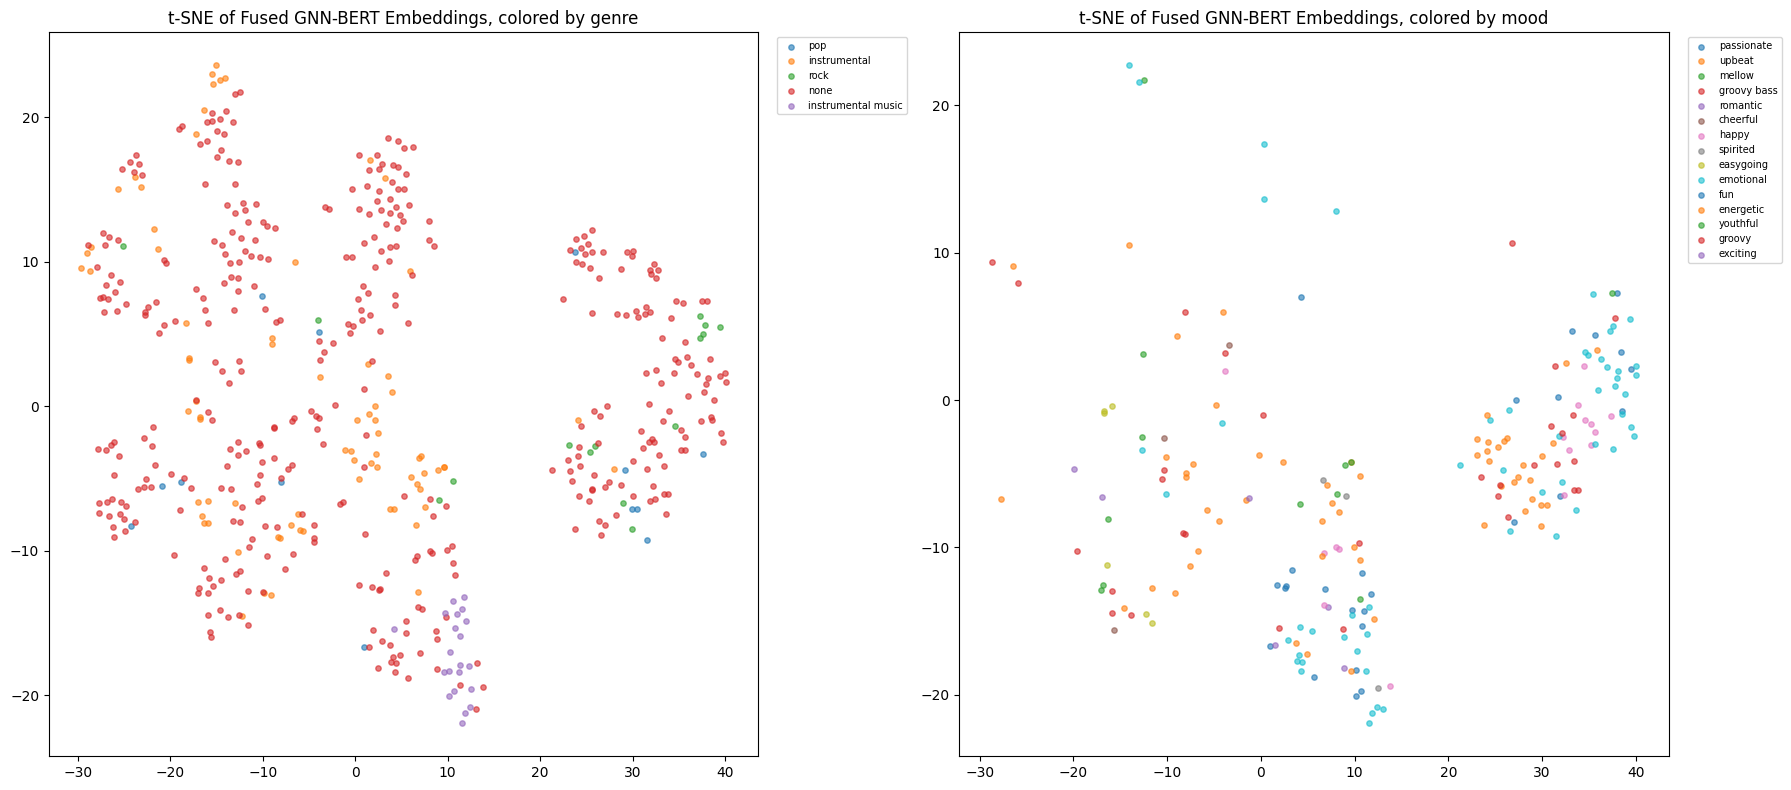


--- Case Study (test idx 3405) ---
Audio file: /kaggle/input/datasets/ayushsharma4045/musiccapsaudio5308/audioFiles/audioFiles/aC3IBcRNyro.wav
Segment graph: 5 nodes (~2.0s each), 12 directed edges
Graph adjacency (segment -> connected segments): {0: [1], 1: [0, 2, 4], 2: [1, 3], 4: [1, 3], 3: [2, 4]}
Original caption: This is an instrumental song featuring a french horn being played. The french horn plays the main melody. This is accompanied by a piano playing arpeg...
Masked caption (aspect keywords -> [MASK] to prevent leakage): This is an [MASK] song featuring a french horn being played. The french horn plays the main melody. This is accompanied by a [MASK] playing arpeggiate...
Actual tags: ['instrumental', 'slow tempo', 'piano', 'no voices', 'romantic', 'bass']
Model top-5 predicted tags (tag, probability): [('instrumental', 0.991), ('piano', 0.988), ('slow tempo', 0.978), ('emotional', 0.45), ('bass', 0.436)]

--- Case Study (test idx 1670) ---
Audio file: /kaggle/input/dataset

In [3]:
"""
TASK 3: GNN-BERT Fusion for Multi-Context Understanding — FIXED / SPEC-COMPLIANT
==================================================================================
Run this in a Kaggle Notebook.

BEFORE RUNNING:
1. Add Input: "MusicCaps" (googleai/musiccaps) — for aspect_list/caption
2. Add Input: "MusicCapsAudio5308" (ayushsharma4045/musiccapsaudio5308) — for audio .wav files
3. (Optional) Add your Task 1 notebook's output as Input, for the BERT warm-start
4. Settings -> Accelerator -> GPU T4 x2

WHAT CHANGED vs. the previous version, and why
------------------------------------------------
The assignment spec (Section 4.3) lists five deliverables for Task 3. The
previous script only satisfied two of them. This version satisfies all five:

  1. End-to-end GNN-BERT fusion model              -> unchanged (Cell 10, 'cross_attention')
  2. Ablation: BERT-only / GNN-only / early-concat  -> NEW (Cell 12): all four
     / cross-attention                                 variants trained & compared
  3. Results (Macro-F1, AUC-PR)                     -> NEW: AUC-PR was missing
                                                        entirely; evaluate() now
                                                        returns it (Cell 11)
  4. t-SNE of z colored by genre AND mood           -> FIXED: previous version
                                                        colored by "top tag" only,
                                                        not genre/mood specifically
                                                        (Cell 14)
  5. 3 case studies showing graph paths +           -> FIXED: previous version
     caption/lyric alignment                           printed caption + audio
                                                        path only, no graph
                                                        structure or predictions
                                                        (Cell 15)

DATASET NOTE: the spec's suggested pairing for Task 3 is FMA-medium or
MagnaTagATune. This script keeps MusicCaps instead, because Task 1's BERT
checkpoint, the cached segment graphs, and Task 4's contrastive retrieval
are all already built on MusicCaps — switching now would break checkpoint
and cache reuse across the whole pipeline. If your instructor requires the
literal FMA-medium/MagnaTagATune pairing, that needs a separate data-loading
cell (different CSV, different label schema) — flag it and I'll write that
version.

MusicCaps has no explicit genre/mood columns, so "genre" and "mood" for the
t-SNE plots are derived from the tag vocabulary itself via keyword rules
(Cell 4b) — e.g. "rock", "pop", "instrumental" -> genre bucket;
"energetic", "happy", "romantic" -> mood bucket. This is a documented
approximation, not ground-truth genre/mood labels.

Copy-paste each "# %% CELL" block into a separate Kaggle notebook cell.
"""

# %% CELL 1 — Install dependencies
!pip install torch-geometric transformers scikit-learn matplotlib -q

# %% CELL 2 — Auto-detect dataset paths
import os

INPUT_ROOT = "/kaggle/input"

def find_path(base_dir, target_name, is_file=False):
    for root, dirs, files_in_dir in os.walk(base_dir):
        if is_file and target_name in files_in_dir:
            return os.path.join(root, target_name)
        if not is_file and target_name in dirs:
            return os.path.join(root, target_name)
    return None

CSV_PATH = find_path(INPUT_ROOT, "musiccaps-public.csv", is_file=True)

def find_wav_root(base_dir):
    for root, dirs, files_in_dir in os.walk(base_dir):
        if any(f.endswith('.wav') for f in files_in_dir):
            return root
    return None

AUDIO_FILES_CANDIDATE = find_path(INPUT_ROOT, "audioFiles")
AUDIO_DIR = find_wav_root(AUDIO_FILES_CANDIDATE) if AUDIO_FILES_CANDIDATE else find_wav_root(INPUT_ROOT)

print(f"CSV_PATH: {CSV_PATH}")
print(f"AUDIO_DIR: {AUDIO_DIR}")
assert CSV_PATH is not None, "musiccaps-public.csv not found — add the MusicCaps dataset"
assert AUDIO_DIR is not None, "No .wav files found — add the MusicCapsAudio5308 dataset"

WORKING_DIR = "/kaggle/working"

TASK1_CHECKPOINT = find_path(INPUT_ROOT, "task1_checkpoint.pt", is_file=True)
print(f"Task 1 checkpoint (optional warm-start): {TASK1_CHECKPOINT}")

# %% CELL 3 — Imports & Config
import re
import ast
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score, average_precision_score, classification_report
from collections import Counter

MAX_LEN = 128
BATCH_SIZE = 8
NUM_EPOCHS = 20          # epochs for the primary (cross-attention) model
ABLATION_EPOCHS = 10     # shorter budget for the 3 comparison variants
TOP_N_TAGS = 50
SEGMENT_DURATION = 2.0
SAMPLE_RATE = 22050
N_CHROMA = 12
SIMILARITY_THRESHOLD = 0.85

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# %% CELL 4 — Load captions, parse aspect_list, build tag vocabulary
df = pd.read_csv(CSV_PATH)
df['aspects_parsed'] = df['aspect_list'].apply(ast.literal_eval)
df['aspects_parsed'] = df['aspects_parsed'].apply(lambda lst: [a.strip().lower() for a in lst])

all_aspects = []
for lst in df['aspects_parsed']:
    all_aspects.extend(lst)
counter = Counter(all_aspects)
TAG_NAMES = [tag for tag, _ in counter.most_common(TOP_N_TAGS)]
NUM_TAGS = len(TAG_NAMES)
print(f"Total tags: {NUM_TAGS}")

def build_labels_and_masked_caption(row):
    aspects_present = set(row['aspects_parsed'])
    labels = np.zeros(NUM_TAGS, dtype=np.float32)
    masked = row['caption']
    for i, tag in enumerate(TAG_NAMES):
        if tag in aspects_present:
            labels[i] = 1.0
            masked = re.sub(re.escape(tag), "[MASK]", masked, flags=re.IGNORECASE)
    return labels, masked

results = df.apply(build_labels_and_masked_caption, axis=1)
df['labels'] = results.apply(lambda r: r[0])
df['masked_caption'] = results.apply(lambda r: r[1])

# %% CELL 4b — NEW: derive pseudo genre/mood buckets from the tag vocabulary
# MusicCaps has no explicit genre/mood columns. We bucket each of the top-50
# tags into a category via keyword rules, so the t-SNE plots required by the
# spec (colored by genre AND mood) have something meaningful to color by.
MOOD_KEYWORDS = ['emotional', 'passionate', 'energetic', 'groovy', 'happy', 'spirited',
                  'romantic', 'exciting', 'upbeat', 'mellow', 'fun', 'cheerful',
                  'easygoing', 'youthful', 'sad', 'calm', 'relaxing', 'dark', 'intense']
GENRE_KEYWORDS = ['rock', 'pop', 'jazz', 'hip-hop', 'hip hop', 'electro', 'electronic',
                   'folk', 'classical', 'country', 'reggae', 'blues', 'metal', 'punk',
                   'funk', 'disco', 'afrobeat', 'latin', 'instrumental']
TEMPO_KEYWORDS = ['tempo', 'uptempo']
VOCAL_KEYWORDS = ['vocal', 'voice', 'singer', 'singing']
INSTRUMENT_KEYWORDS = ['guitar', 'drum', 'bass', 'piano', 'kick', 'snare', 'hat',
                        'percussion', 'keyboard', 'synth', 'strings', 'brass', 'violin']
PRODUCTION_KEYWORDS = ['quality', 'noisy', 'amateur', 'live performance', 'mono', 'loud', 'studio']

def categorize_tag(tag):
    t = tag.lower()
    if any(k in t for k in MOOD_KEYWORDS):
        return 'mood'
    if any(k in t for k in TEMPO_KEYWORDS):
        return 'tempo'
    if any(k in t for k in VOCAL_KEYWORDS):
        return 'vocal'
    if any(k in t for k in INSTRUMENT_KEYWORDS):
        return 'instrument'
    if any(k in t for k in PRODUCTION_KEYWORDS):
        return 'production'
    if any(k in t for k in GENRE_KEYWORDS):
        return 'genre'
    return 'other'

TAG_CATEGORY = {tag: categorize_tag(tag) for tag in TAG_NAMES}
MOOD_TAG_IDX = [i for i, t in enumerate(TAG_NAMES) if TAG_CATEGORY[t] == 'mood']
GENRE_TAG_IDX = [i for i, t in enumerate(TAG_NAMES) if TAG_CATEGORY[t] == 'genre']
print(f"Mood-bucket tags ({len(MOOD_TAG_IDX)}): {[TAG_NAMES[i] for i in MOOD_TAG_IDX]}")
print(f"Genre-bucket tags ({len(GENRE_TAG_IDX)}): {[TAG_NAMES[i] for i in GENRE_TAG_IDX]}")

def dominant_label(label_vec, idx_list, fallback='none'):
    present = [TAG_NAMES[i] for i in idx_list if label_vec[i] == 1.0]
    return present[0] if present else fallback

# %% CELL 5 — Match ytid to actual audio files (robust matching)
def normalize_id(s):
    s = s[:-4] if s.endswith('.wav') else s
    if s.startswith('-') or s.startswith('_'):
        s = s[1:]
    return s

wav_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')]
normalized_lookup = {normalize_id(f): f for f in wav_files}

def find_audio_file(ytid):
    key = normalize_id(ytid)
    return os.path.join(AUDIO_DIR, normalized_lookup[key]) if key in normalized_lookup else None

df['audio_path'] = df['ytid'].apply(find_audio_file)
df_matched = df[df['audio_path'].notna()].reset_index(drop=True)
print(f"Matched {len(df_matched)} / {len(df)} captions to audio files")
assert len(df_matched) > 0, "No matches found — check AUDIO_DIR contents and ytid format"

# %% CELL 6 — Audio to Segment Graph builder (same approach as Task 2, chroma-only)
def build_segment_graph(audio_path, segment_duration=SEGMENT_DURATION, sr=SAMPLE_RATE):
    try:
        y, _ = librosa.load(audio_path, sr=sr, duration=10)
    except Exception:
        return None
    if len(y) < sr:
        return None

    hop_length = 512
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=hop_length)
    frames_per_segment = int(segment_duration * sr / hop_length)
    n_segments = max(1, chroma.shape[1] // frames_per_segment)

    node_features = []
    for i in range(n_segments):
        start = i * frames_per_segment
        end = min(start + frames_per_segment, chroma.shape[1])
        node_features.append(chroma[:, start:end].mean(axis=1))

    if len(node_features) < 2:
        return None
    node_features = np.stack(node_features)

    edges = []
    for i in range(len(node_features)):
        if i + 1 < len(node_features):
            edges.append([i, i + 1]); edges.append([i + 1, i])
        for j in range(i + 1, len(node_features)):
            sim = np.dot(node_features[i], node_features[j]) / (
                np.linalg.norm(node_features[i]) * np.linalg.norm(node_features[j]) + 1e-8)
            if sim > SIMILARITY_THRESHOLD:
                edges.append([i, j]); edges.append([j, i])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    x = torch.tensor(node_features, dtype=torch.float)
    return x, edge_index

# %% CELL 7 — Preprocess into graph cache (skip if already cached from a previous session)
GRAPH_CACHE_DIR = os.path.join(WORKING_DIR, "task3_graphs_cache")
EXISTING_CACHE = find_path(INPUT_ROOT, "task3_graphs_cache")
if EXISTING_CACHE is not None and len(os.listdir(EXISTING_CACHE)) > 0:
    GRAPH_CACHE_DIR = EXISTING_CACHE
    print(f"Reusing existing graph cache: {GRAPH_CACHE_DIR}")
else:
    os.makedirs(GRAPH_CACHE_DIR, exist_ok=True)

def preprocess_all():
    processed, skipped = 0, 0
    for idx, row in df_matched.iterrows():
        cache_path = os.path.join(GRAPH_CACHE_DIR, f"{idx}.pt")
        if os.path.exists(cache_path):
            continue
        result = build_segment_graph(row['audio_path'])
        if result is None:
            skipped += 1
            continue
        x, edge_index = result
        torch.save({'x': x, 'edge_index': edge_index}, cache_path)
        processed += 1
        if processed % 500 == 0:
            print(f"Processed: {processed}, Skipped: {skipped}")
    print(f"DONE. Processed: {processed}, Skipped: {skipped}")

if EXISTING_CACHE is None:
    preprocess_all()

valid_indices = [i for i in range(len(df_matched)) if os.path.exists(os.path.join(GRAPH_CACHE_DIR, f"{i}.pt"))]
df_final = df_matched.iloc[valid_indices].reset_index(drop=True)
graph_files = [os.path.join(GRAPH_CACHE_DIR, f"{i}.pt") for i in valid_indices]
print(f"Final usable samples: {len(df_final)}")

# %% CELL 8 — Train/Val/Test split
from sklearn.model_selection import train_test_split

indices = list(range(len(df_final)))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# %% CELL 9 — Dataset class (graph + tokenized masked caption + labels)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class FusionDataset(TorchDataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        row = df_final.iloc[idx]
        graph_data = torch.load(graph_files[idx], weights_only=False)
        encoding = tokenizer(
            row['masked_caption'], truncation=True, padding='max_length',
            max_length=MAX_LEN, return_tensors='pt'
        )
        return {
            'x': graph_data['x'],
            'edge_index': graph_data['edge_index'],
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(row['labels'], dtype=torch.float)
        }

def collate_fn(batch):
    x_list, edge_index_list, batch_idx = [], [], []
    node_offset = 0
    for i, item in enumerate(batch):
        x_list.append(item['x'])
        edge_index_list.append(item['edge_index'] + node_offset)
        batch_idx.extend([i] * item['x'].shape[0])
        node_offset += item['x'].shape[0]

    return {
        'x': torch.cat(x_list, dim=0),
        'edge_index': torch.cat(edge_index_list, dim=1),
        'batch': torch.tensor(batch_idx, dtype=torch.long),
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'labels': torch.stack([b['labels'] for b in batch]),
    }

train_loader = DataLoader(FusionDataset(train_idx), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(FusionDataset(val_idx), batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(FusionDataset(test_idx), batch_size=BATCH_SIZE, collate_fn=collate_fn)

# %% CELL 10 — NEW: Unified model supporting all 4 ablation variants
class GNNEncoder(nn.Module):
    """Same architecture as Task 2's GraphSAGE, outputs a graph embedding."""
    def __init__(self, in_channels=N_CHROMA, hidden_channels=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList([SAGEConv(in_channels, hidden_channels)])
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = self.dropout(x)
        return global_mean_pool(x, batch)


class UnifiedFusionModel(nn.Module):
    """
    fusion_type in {'bert_only', 'gnn_only', 'early_concat', 'cross_attention'}.
    Required by spec Section 4.3 deliverable #2: ablation across all four.
    """
    def __init__(self, fusion_type, num_tags=NUM_TAGS, gnn_hidden=64, bert_hidden=768):
        super().__init__()
        assert fusion_type in ('bert_only', 'gnn_only', 'early_concat', 'cross_attention')
        self.fusion_type = fusion_type

        if fusion_type != 'bert_only':
            self.gnn = GNNEncoder(hidden_channels=gnn_hidden)
        if fusion_type != 'gnn_only':
            self.bert = BertModel.from_pretrained('bert-base-uncased')

        if fusion_type == 'cross_attention':
            self.query_proj = nn.Linear(gnn_hidden, bert_hidden)
            self.attn = nn.MultiheadAttention(embed_dim=bert_hidden, num_heads=8, batch_first=True)
            classifier_in = gnn_hidden + bert_hidden
        elif fusion_type == 'early_concat':
            classifier_in = gnn_hidden + bert_hidden
        elif fusion_type == 'gnn_only':
            classifier_in = gnn_hidden
        else:  # bert_only
            classifier_in = bert_hidden

        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_tags)
        )

    def forward(self, x, edge_index, batch, input_ids, attention_mask):
        if self.fusion_type == 'bert_only':
            t = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
            return self.classifier(t)

        if self.fusion_type == 'gnn_only':
            g = self.gnn(x, edge_index, batch)
            return self.classifier(g)

        g = self.gnn(x, edge_index, batch)
        Htext = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        if self.fusion_type == 'early_concat':
            t_cls = Htext[:, 0, :]
            z = torch.cat([g, t_cls], dim=1)
            return self.classifier(z)

        # cross_attention
        q = self.query_proj(g).unsqueeze(1)
        attended, _ = self.attn(q, Htext, Htext, key_padding_mask=(attention_mask == 0))
        z = torch.cat([g, attended.squeeze(1)], dim=1)
        return self.classifier(z)

    def get_fused_embedding(self, x, edge_index, batch, input_ids, attention_mask):
        """Only defined for cross_attention — used for the t-SNE cell."""
        assert self.fusion_type == 'cross_attention'
        g = self.gnn(x, edge_index, batch)
        Htext = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        q = self.query_proj(g).unsqueeze(1)
        attended, _ = self.attn(q, Htext, Htext, key_padding_mask=(attention_mask == 0))
        return torch.cat([g, attended.squeeze(1)], dim=1)


def maybe_warm_start_bert(model):
    if TASK1_CHECKPOINT is not None and hasattr(model, 'bert'):
        ckpt = torch.load(TASK1_CHECKPOINT, weights_only=False)
        bert_state = {k.replace('bert.', ''): v for k, v in ckpt['model_state'].items() if k.startswith('bert.')}
        model.bert.load_state_dict(bert_state, strict=False)
        return True
    return False

# %% CELL 11 — NEW: training/eval helpers, now with AUC-PR
criterion = nn.BCEWithLogitsLoss()

def train_epoch(model, optimizer, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        x = batch['x'].to(device)
        edge_index = batch['edge_index'].to(device)
        b_idx = batch['batch'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(x, edge_index, b_idx, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for batch in loader:
        x = batch['x'].to(device)
        edge_index = batch['edge_index'].to(device)
        b_idx = batch['batch'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(x, edge_index, b_idx, input_ids, attention_mask)
        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)

    # AUC-PR (spec Section 6): mean average precision over tags that have at
    # least one positive example in this split (undefined otherwise).
    valid_tags = [k for k in range(all_labels.shape[1]) if all_labels[:, k].sum() > 0]
    if valid_tags:
        auc_pr = average_precision_score(all_labels[:, valid_tags], all_probs[:, valid_tags], average='macro')
    else:
        auc_pr = float('nan')

    return {'macro_f1': macro_f1, 'micro_f1': micro_f1, 'auc_pr': auc_pr}, all_probs, all_preds, all_labels

# %% CELL 12 — NEW: Ablation study (spec deliverable #2)
# Trains all four fusion variants and compares them. The primary
# 'cross_attention' model gets the full NUM_EPOCHS budget with
# checkpoint/resume support; the other three get ABLATION_EPOCHS since
# they exist purely for comparison, not as the final deliverable model.
FUSION_TYPES = ['bert_only', 'gnn_only', 'early_concat', 'cross_attention']
ablation_results = {}
models = {}

for fusion_type in FUSION_TYPES:
    print(f"\n{'='*60}\nTraining variant: {fusion_type}\n{'='*60}")
    model = UnifiedFusionModel(fusion_type).to(device)
    warm_started = maybe_warm_start_bert(model)
    if warm_started:
        print("Warm-started BERT weights from Task 1 checkpoint.")

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    epochs = NUM_EPOCHS if fusion_type == 'cross_attention' else ABLATION_EPOCHS
    ckpt_path = os.path.join(WORKING_DIR, f"task3_{fusion_type}_checkpoint.pt")

    start_epoch = 0
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Resumed {fusion_type} from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs):
        train_loss = train_epoch(model, optimizer, train_loader)
        val_metrics, _, _, _ = evaluate(model, val_loader)
        print(f"[{fusion_type}] Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | "
              f"Val Macro-F1: {val_metrics['macro_f1']:.4f} | Val AUC-PR: {val_metrics['auc_pr']:.4f}")
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict()}, ckpt_path)

    test_metrics, _, _, _ = evaluate(model, test_loader)
    ablation_results[fusion_type] = test_metrics
    models[fusion_type] = model
    print(f"[{fusion_type}] TEST — Macro-F1: {test_metrics['macro_f1']:.4f} | "
          f"Micro-F1: {test_metrics['micro_f1']:.4f} | AUC-PR: {test_metrics['auc_pr']:.4f}")

main_model = models['cross_attention']  # the primary deliverable model

# %% CELL 13 — NEW: Ablation comparison table (spec Table 3 style)
print(f"\n{'='*70}\nTASK 3 — ABLATION COMPARISON (spec Section 4.3 / Table 3)\n{'='*70}")
print(f"{'Model':<20}{'Macro-F1':<12}{'Micro-F1':<12}{'AUC-PR':<12}")
label_map = {'bert_only': 'BERT-only', 'gnn_only': 'GNN-only',
             'early_concat': 'Early-concat', 'cross_attention': 'Cross-attention (ours)'}
for ft in FUSION_TYPES:
    m = ablation_results[ft]
    print(f"{label_map[ft]:<20}{m['macro_f1']:<12.4f}{m['micro_f1']:<12.4f}{m['auc_pr']:<12.4f}")

# %% CELL 14 — FIXED: t-SNE colored by genre AND by mood (spec deliverable #4)
from sklearn.manifold import TSNE

@torch.no_grad()
def get_fused_embeddings_and_labels(model, loader):
    model.eval()
    embeddings, mood_labels, genre_labels = [], [], []
    for batch in loader:
        x = batch['x'].to(device)
        edge_index = batch['edge_index'].to(device)
        b_idx = batch['batch'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].numpy()

        z = model.get_fused_embedding(x, edge_index, b_idx, input_ids, attention_mask)
        embeddings.append(z.cpu().numpy())
        for lbl in labels:
            mood_labels.append(dominant_label(lbl, MOOD_TAG_IDX))
            genre_labels.append(dominant_label(lbl, GENRE_TAG_IDX))
    return np.concatenate(embeddings), mood_labels, genre_labels

embeddings, mood_labels, genre_labels = get_fused_embeddings_and_labels(main_model, test_loader)
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) - 1))
proj = tsne.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, group_labels, title in [(axes[0], genre_labels, "colored by genre"),
                                  (axes[1], mood_labels, "colored by mood")]:
    unique_vals = list(set(group_labels))[:15]  # cap legend at 15 for readability
    for val in unique_vals:
        mask = [g == val for g in group_labels]
        ax.scatter(proj[mask, 0], proj[mask, 1], label=val, alpha=0.6, s=15)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    ax.set_title(f"t-SNE of Fused GNN-BERT Embeddings, {title}")
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, "task3_tsne_genre_mood.png"), dpi=150)
plt.show()

# %% CELL 15 — FIXED: case studies with graph paths + caption/lyric alignment
# spec deliverable #5 explicitly asks for "graph paths + caption/lyric
# alignment" — the previous version only printed the audio path and caption.
# This version prints: segment-graph structure (nodes + adjacency), which
# words were masked out for label-leakage prevention (the alignment between
# graph segments and text is implicit in "same clip, same tags"), and the
# model's actual top-5 predicted tags next to the ground truth so the
# alignment between graph-driven prediction and text is visible.
main_model.eval()
np.random.seed(7)
sample_indices = np.random.choice(len(test_idx), min(3, len(test_idx)), replace=False)

for i in sample_indices:
    idx = test_idx[i]
    row = df_final.iloc[idx]
    graph_data = torch.load(graph_files[idx], weights_only=False)
    x, edge_index = graph_data['x'], graph_data['edge_index']

    adjacency = {}
    for e in range(edge_index.shape[1]):
        src, dst = edge_index[0, e].item(), edge_index[1, e].item()
        adjacency.setdefault(src, set()).add(dst)
    adjacency = {k: sorted(v) for k, v in adjacency.items()}

    encoding = tokenizer(row['masked_caption'], truncation=True, padding='max_length',
                          max_length=MAX_LEN, return_tensors='pt')
    with torch.no_grad():
        logits = main_model(
            x.to(device), edge_index.to(device),
            torch.zeros(x.shape[0], dtype=torch.long).to(device),
            encoding['input_ids'].to(device), encoding['attention_mask'].to(device)
        )
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    top5_idx = np.argsort(probs)[::-1][:5]
    predicted = [(TAG_NAMES[j], round(float(probs[j]), 3)) for j in top5_idx]
    actual = [TAG_NAMES[j] for j, v in enumerate(row['labels']) if v == 1.0]

    print(f"\n--- Case Study (test idx {idx}) ---")
    print(f"Audio file: {row['audio_path']}")
    print(f"Segment graph: {x.shape[0]} nodes (~{SEGMENT_DURATION}s each), "
          f"{edge_index.shape[1]} directed edges")
    print(f"Graph adjacency (segment -> connected segments): {adjacency}")
    print(f"Original caption: {row['caption'][:150]}...")
    print(f"Masked caption (aspect keywords -> [MASK] to prevent leakage): {row['masked_caption'][:150]}...")
    print(f"Actual tags: {actual}")
    print(f"Model top-5 predicted tags (tag, probability): {predicted}")

# %% CELL 16 — Save results
RESULTS_PATH = os.path.join(WORKING_DIR, "task3_results.json")
results = {
    "ablation_results": ablation_results,
    "primary_model": "cross_attention",
    "tag_names": TAG_NAMES,
    "tag_categories": TAG_CATEGORY,
    "num_samples": len(df_final),
}
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

torch.save({'model_state': main_model.state_dict()}, os.path.join(WORKING_DIR, "task3_checkpoint.pt"))

print(f"Results saved at: {RESULTS_PATH}")
print("\nIMPORTANT: click 'Save Version' (top right) now, or these files")
print("will be lost when this session ends.")